In [1]:
!pip -q install PyALE

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from PyALE import ale

# Impostazioni globali per i plot
sns.set_palette("husl")

# Caricamento dei dati
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Divisione dei dati in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [2]:
rrr = RandomForestRegressor()

In [3]:
rrr.fit(np.array(X_train), np.array(y_train))

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
predictions = rrr.predict(np.array(X_test))

In [ ]:
pi_train = permutation_importance(X=X_train, estimator=rrr, y=y_train)

In [11]:
pi_test = permutation_importance(X=X_test, estimator=rrr, y=y_test)

c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  

In [12]:
pi_test

{'importances_mean': array([-0.00478899,  0.01369897,  0.18664118,  0.01397522, -0.00704387,
        -0.00898966,  0.00448095, -0.00457412,  0.23357577,  0.02731935]),
 'importances_std': array([0.0186128 , 0.00572568, 0.03664158, 0.02133624, 0.01001011,
        0.01229901, 0.00955716, 0.00424207, 0.05810294, 0.01015053]),
 'importances': array([[ 0.01813084, -0.02022676,  0.00401592,  0.0065403 , -0.03240527],
        [ 0.0241451 ,  0.00796923,  0.01282795,  0.01440433,  0.00914823],
        [ 0.16577208,  0.19896296,  0.1432299 ,  0.17459882,  0.25064214],
        [-0.0250115 ,  0.01039128,  0.03777454,  0.02273688,  0.02398487],
        [-0.00982813,  0.00627303, -0.01297824,  0.00227878, -0.02096476],
        [ 0.00364069,  0.00389547, -0.01011184, -0.01306229, -0.02931035],
        [-0.00778824,  0.01199003,  0.00399739, -0.00375527,  0.01796085],
        [-0.00164813, -0.00069466, -0.00330938, -0.01262174, -0.00459669],
        [ 0.25912817,  0.2265846 ,  0.1276617 ,  0.30117819,

In [15]:
np.arange(0, len(X.columns))

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

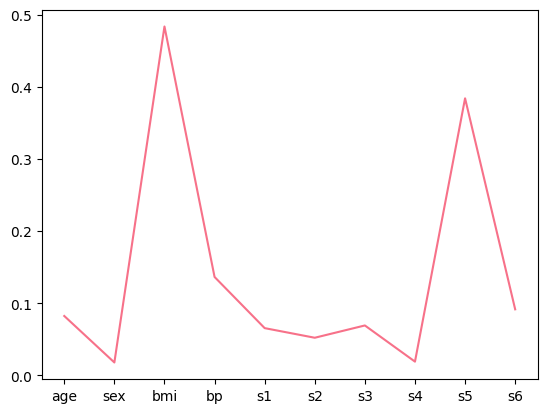

In [ ]:
plt.plot(np.arange(0, len(X.columns)), pi_train.importances_mean)
plt.xticks(np.arange(len(X.columns)), diabetes.feature_names)
plt.show()

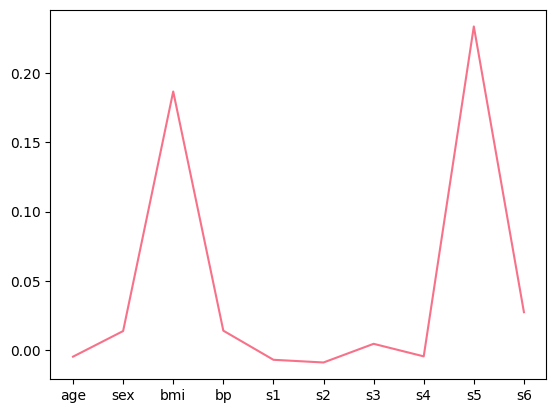

In [32]:
plt.plot(np.arange(0, len(X.columns)), pi_test.importances_mean)
plt.xticks(np.arange(len(X.columns)), diabetes.feature_names)
plt.show()

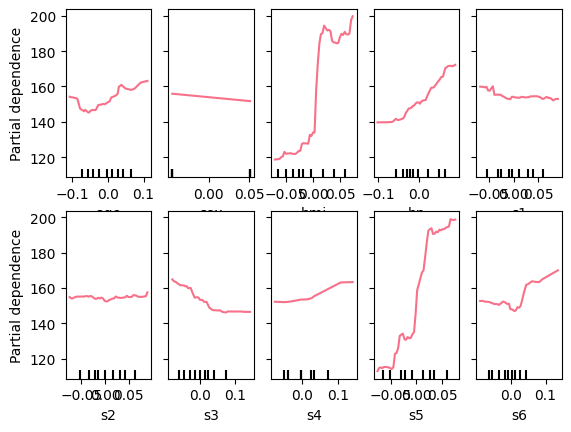

In [38]:
pdp = PartialDependenceDisplay.from_estimator(
    X=X_test,
    features=range(10),
    estimator=rrr,
    feature_names=diabetes.feature_names,
    grid_resolution=50,
    n_cols=5,
    n_jobs=2
)

PyALE._ALE_generic:INFO: Continuous feature detected.
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


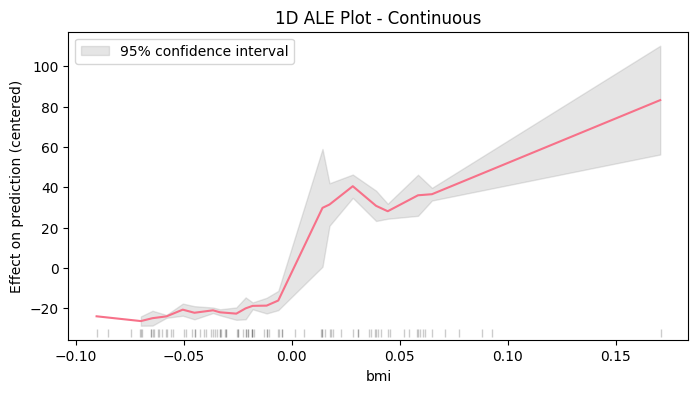

In [4]:
ale_single = ale(
    X=X_test,
    model=rrr,
    feature=["bmi"],
    grid_size=20
)

c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


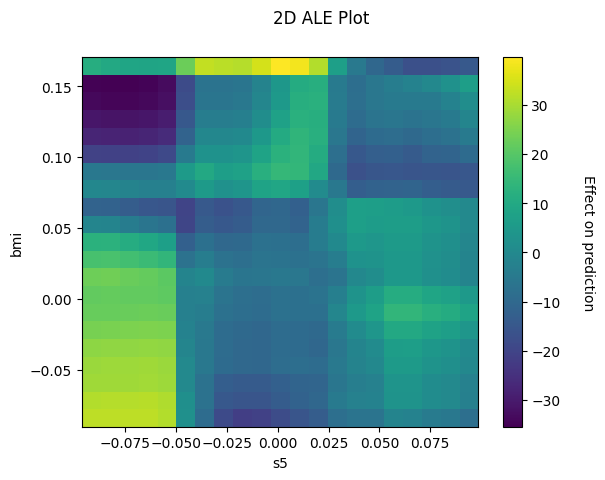

In [6]:
ale_double = ale(
    X=X_test,
    model=rrr,
    feature=["bmi","s5"],
    grid_size=20
)